In [2]:
### Display
from IPython.display import display
## Data Handling
import pandas as pd
import pm4py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import numpy as np
from cvxopt.misc_solvers import scale


In [3]:
# please do not change or delete this cell (probably not needed, but just in case ;))
random.seed(42)
np.random.seed(42)

In [4]:
log = pm4py.read_xes('fines_event_log.xes', variant="rustxes")
log

,penalty,paymentAmount,case:fine,case:concept:name,expense,time:timestamp,concept:name,dismissal
0,NaN,NaN,3500,A1,NaN,2006-07-23 22:00:00+00:00,Create Fine,None
1,NaN,NaN,3500,A1,1100.0,2006-12-04 23:00:00+00:00,Send Fine,None
2,NaN,NaN,3600,A10008,NaN,2007-03-19 23:00:00+00:00,Create Fine,None
3,NaN,NaN,3600,A10008,1300.0,2007-07-16 22:00:00+00:00,Send Fine,None
4,NaN,NaN,3600,A10008,NaN,2007-08-01 22:00:00+00:00,Insert Fine Notification,None
...,...,...,...,...,...,...,...,...
267247,NaN,NaN,13100,V9999,NaN,2002-09-06 22:00:00+00:00,Create Fine,None
267248,NaN,NaN,13100,V9999,1516.0,2002-10-24 22:00:00+00:00,Send Fine,None
267249,NaN,NaN,13100,V9999,NaN,2002-11-03 23:00:00+00:00,Insert Fine Notification,None
267250,13100.0,NaN,13100,V9999,NaN,2003-01-02 23:00:00+00:00,Add penalty,None


In [5]:
# number of cases
number_cases = log["case:concept:name"].nunique()
number_cases

71522

In [6]:
number_activities = log["concept:name"].nunique()
number_activities

11

# a) Full Model Discovery

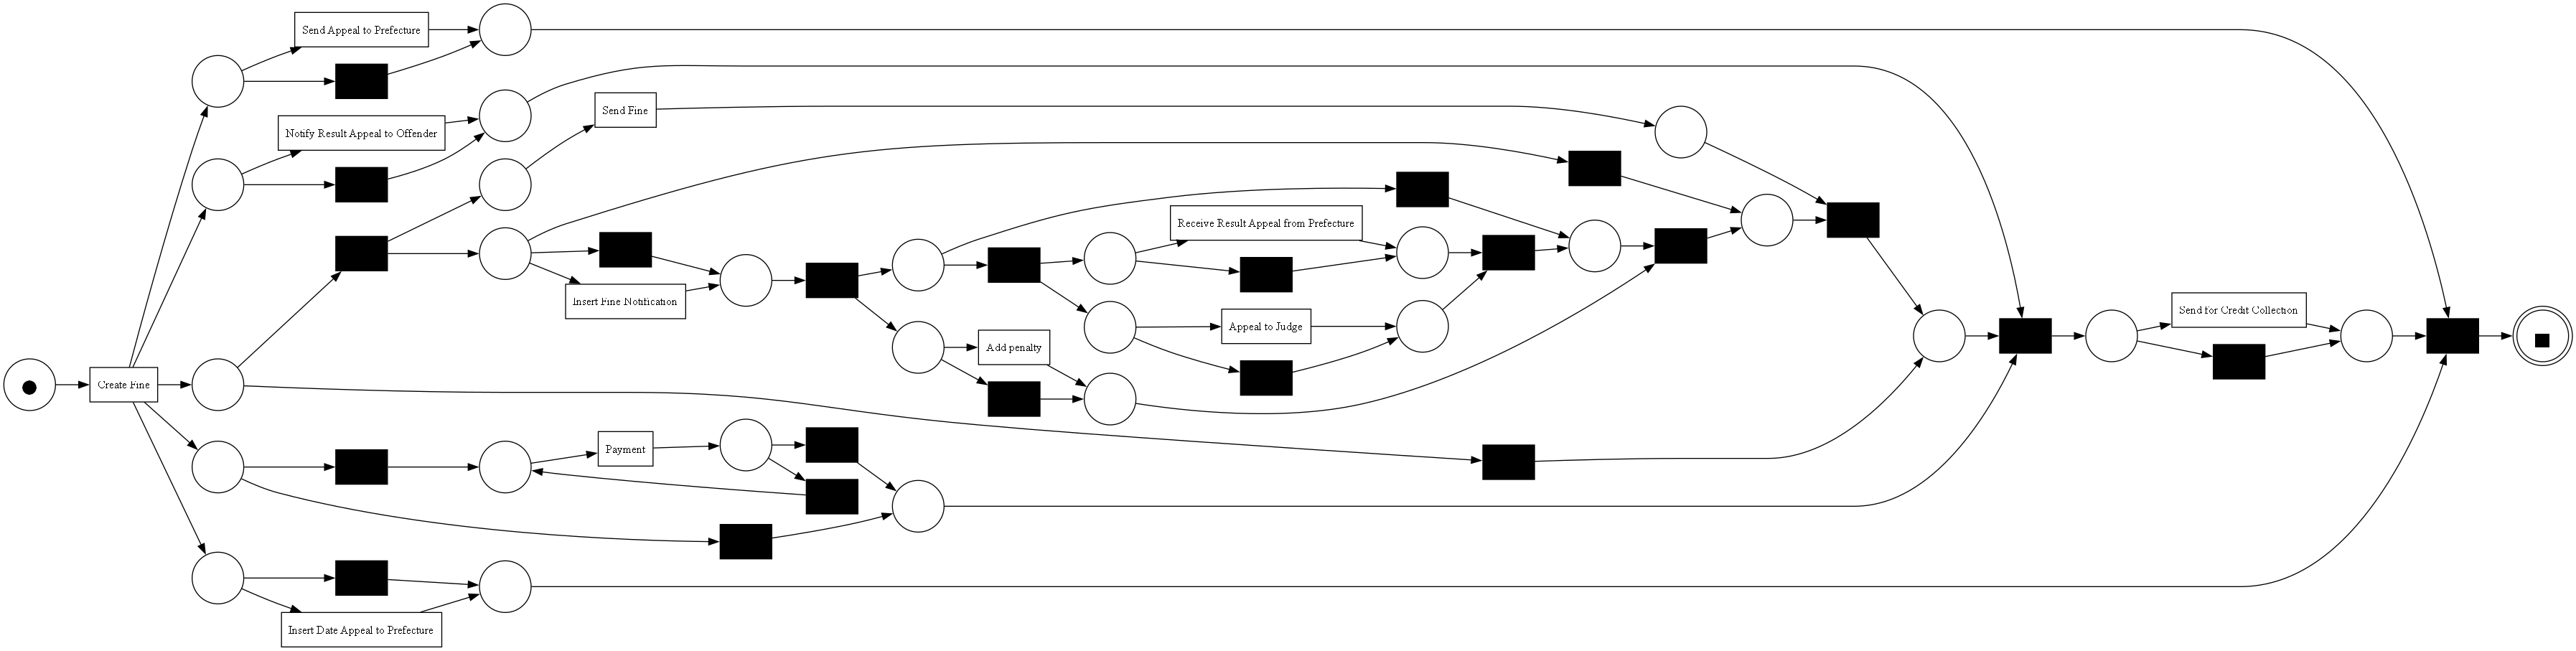

In [7]:
petrinet, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)
pm4py.view_petri_net(petrinet,initial_marking,final_marking, format="png")

- Create fine is the only start activity in the petri net
- Only Create fine has to be executed before Appeal to Judge can be executed (because of silent transitions)
- Only the payment activity is part of a loop and can therefore be executed multiple times
- The model allows for a path that involves the Credit Collection to be involved without the Send Fine activity to be executed

# b) Behavior Case Frequency

For this question, we recommend using the following event log filtering methods of PM4PY:
- filter_eventually_follows_relation (https://processintelligence.solutions/static/api/2.7.17/generated/pm4py.filtering.filter_eventually_follows_relation.html)
- filter_directly_follows_relation (https://processintelligence.solutions/static/api/2.7.17/generated/pm4py.filtering.filter_directly_follows_relation.html)

In [8]:
print("Amount of cases that:")
print("Go to collections after payment:\t"+str(len(pm4py.filter_eventually_follows_relation(log,[("Payment", "Send for Credit Collection")])["case:concept:name"].unique())))
print("Add a fine before being send out:\t"+str(len(pm4py.filter_eventually_follows_relation(log,[("Add penalty", "Send Fine")])["case:concept:name"].unique())))
print("Appeal to anyone after payment sent:\t"+str(len(pm4py.filter_eventually_follows_relation(log,[("Payment", "Appeal to Judge"),("Payment", "Send Appeal to Prefecture"),("Payment","Insert Date Appeal to Prefecture")])["case:concept:name"].unique())))

##For the last question, we subtract results with appeals from the count of all results
resultsCount = len(pm4py.filter_eventually_follows_relation(log, [("Create Fine", "Notify Result Appeal to Offender")])["case:concept:name"].unique())
resultsAfterAppealCount = len(pm4py.filter_eventually_follows_relation(log, [("Appeal to Judge", "Notify Result Appeal to Offender"), ("Send Appeal to Prefecture", "Notify Result Appeal to Offender"),("Insert Date Appeal to Prefecture", "Notify Result Appeal to Offender")])["case:concept:name"].unique())
print("Notification of result without appeal:\t"+str(resultsCount-resultsAfterAppealCount))

Amount of cases that:
Go to collections after payment:	1013
Add a fine before being send out:	0
Appeal to anyone after payment sent:	10
Notification of result without appeal:	5


# c) Variants

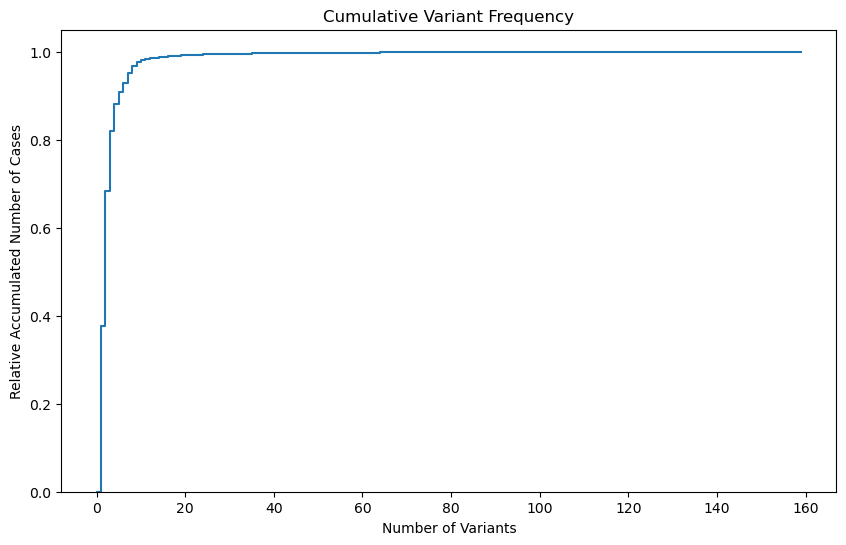

Top 5 Variants and their Case Counts:
                                             Variant  Count
0  (Create Fine, Send Fine, Insert Fine Notificat...  26872
1                             (Create Fine, Payment)  22078
2                           (Create Fine, Send Fine)   9631
3  (Create Fine, Send Fine, Insert Fine Notificat...   4507
4  (Create Fine, Send Fine, Insert Fine Notificat...   1806


In [9]:
# Compute the variants
variants = pm4py.get_variants(log)

# Get the counts of each variant
var_counts = []
for k, v in variants.items():
    count = len(v) if isinstance(v, list) else v
    var_counts.append((k, count))

# Create DataFrame and Sort by frequency
df_variants = pd.DataFrame(var_counts, columns=['Variant', 'Count']).sort_values('Count', ascending=False).reset_index(drop=True)

# Create the total count
total_cases = df_variants['Count'].sum()

# Add 0 variant and plot
counts = [0] + df_variants['Count'].tolist()
cumulative_rel_freq = [sum(counts[:i+1])/total_cases for i in range(len(counts))]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(cumulative_rel_freq)), cumulative_rel_freq, drawstyle='steps-post')
ax.set_xlabel("Number of Variants")
ax.set_ylabel("Relative Accumulated Number of Cases")
ax.set_title("Cumulative Variant Frequency")
ax.set_ylim(0, 1.05)
plt.show()

# Print 5 most popular variants
top_5 = pd.DataFrame(df_variants.sort_values('Count', ascending=False)[:5])
print("Top 5 Variants and their Case Counts:")
print(top_5)

Interpretation of the chart: Chart shows that the vast majority of cases is covered by 2-3 variants. The vast majority of variants only cover a limited number of cases.

# d) Case overview

In [10]:
## Aggregate values according to rules
case_summary = log.groupby("case:concept:name").agg({
    "case:fine": "first",     
    "expense": "max",
    "penalty": "max", 
    "paymentAmount": "sum"
}).fillna(0)

# Calculate if the payment is greater than or equal to the sum of dues 
case_summary["is_paid_off"] = (
    case_summary["paymentAmount"] >= 
    (case_summary["case:fine"] + case_summary["expense"] + case_summary["penalty"])
)

# Extract the index of cases that are closed because they were paid
paidCases = case_summary[case_summary["is_paid_off"]].index

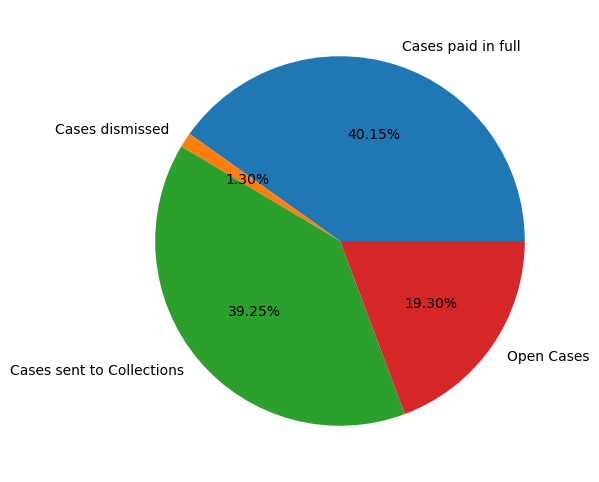

In [11]:
## Find cases that were dismissed. We need only to look at the last entry.
log_last_entry = log.sort_values("time:timestamp", ascending=False).drop_duplicates("case:concept:name")
dismissedCases = log_last_entry[log_last_entry["dismissal"].notna()]["case:concept:name"].values

## Find cases that were sent to credit collection.
log_credit_collections = log[log["concept:name"] == "Send for Credit Collection"]
collectionCases = log_credit_collections["case:concept:name"]

## Combine all three cases
totalResolvedCases = list(paidCases)
totalResolvedCases.extend(list(dismissedCases))
totalResolvedCases.extend(list(collectionCases))

## Check if there are duplicate entries
uniqueSet = set()
uniqueSet.update(totalResolvedCases)
if len(uniqueSet) - len(totalResolvedCases) != 0:
    raise Exception("Duplicate values in total resolved cases")

openCaseCount = len(log["case:concept:name"].unique())-len(totalResolvedCases)

## Plot the pie
labels = ["Cases paid in full", "Cases dismissed", "Cases sent to Collections", "Open Cases"]
values = [len(paidCases), len(dismissedCases), len(collectionCases), openCaseCount]

fig, ax = plt.subplots(figsize=(11,6))
ax.pie(values,labels=labels,autopct='%1.2f%%')
plt.show()

# e) Filtered log

Cases: 57720
Top-5 closed-case variants: 55314
Top-5 variants:
26872 ('Create Fine', 'Send Fine', 'Insert Fine Notification', 'Add penalty', 'Send for Credit Collection')
22053 ('Create Fine', 'Payment')
3329 ('Create Fine', 'Send Fine', 'Insert Fine Notification', 'Add penalty', 'Payment')
1683 ('Create Fine', 'Send Fine', 'Insert Fine Notification', 'Add penalty', 'Payment', 'Payment')
1377 ('Create Fine', 'Send Fine', 'Payment')


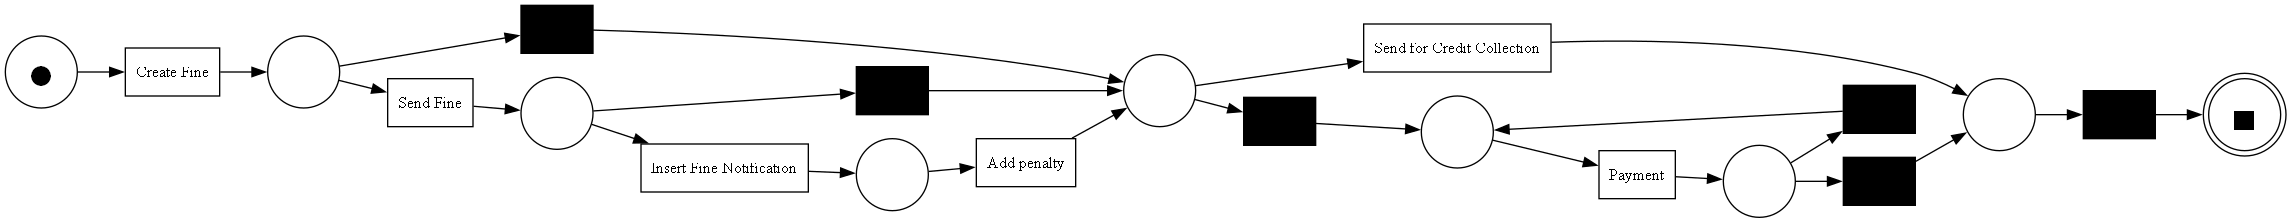

In [12]:

filtered_log  = log.loc[log["case:concept:name"].isin(set(dismissedCases) | set(paidCases) | set(collectionCases))]

print("Cases:", filtered_log["case:concept:name"].nunique())


log_obj = pm4py.convert_to_event_log(filtered_log)

log_var_k5 = pm4py.filter_variants_top_k(log_obj, 5)

variant_counts = pm4py.get_variants_as_tuples(filtered_log)  # {variant_tuple: count}
top_k_variants = sorted(variant_counts.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top-5 closed-case variants:", len(log_var_k5))

print("Top-5 variants:")
for v, c in top_k_variants:
    print(c, v)


net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log_var_k5)
pm4py.view_petri_net(net, initial_marking, final_marking)

# f) Fitness

In [14]:
token_replay_result =  pm4py.fitness_token_based_replay(log=log, petri_net=net, initial_marking=initial_marking, final_marking=final_marking)
display(token_replay_result)

replaying log with TBR, completed traces ::   0%|          | 0/159 [00:00<?, ?it/s]

{'perc_fit_traces': 80.25782276781969,
 'average_trace_fitness': 0.9462410851920374,
 'log_fitness': 0.9708997543726612,
 'percentage_of_fitting_traces': 80.25782276781969}